In [1]:
import os, sys
import warnings
import time

import pandas as pd
import numpy as np
import math

import pickle

from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.graph_objects as go
from matplotlib.lines import Line2D
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

import lifelines
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test
from sksurv.util import Surv
from sksurv.metrics import concordance_index_ipcw

import tensorflow as tf
import tensorflow_probability as tfp

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

import scipy.stats as stats
from scipy.stats import norm, t, probplot, pearsonr, spearmanr, rankdata
from scipy.stats import truncnorm as truncnorm_scipy
from scipy.stats import gamma as gamma_dist
from scipy.special import gamma

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold

# import thetaflow as thf
import modelnn2 as thf

import json
import gc
import glob
from pathlib import Path

sys.path.append("../")
import gndr_utils as utils

I0000 00:00:1781090027.487311   13572 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781090027.533689   13572 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781090028.589109   13572 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781090029.469008   13572 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device

In [2]:
import pyarrow.parquet as pq

# Access metadata without loading data
metadata_train = pq.read_metadata('../Cross Validation Data/train_data_small.parquet')
metadata_test = pq.read_metadata('../Cross Validation Data/test_data_small.parquet')
# metadata_train = pq.read_metadata('../../train_data.parquet')
# metadata_test = pq.read_metadata('../../test_data.parquet')

# Get shape: (rows, columns)
num_rows_train = metadata_train.num_rows
num_cols_train = metadata_train.num_columns
num_rows_test = metadata_test.num_rows

# The number of features is given by the total number of columns minus the time and event indicator columns
n_features = num_cols_train - 2

n_train = num_rows_train
n_test = num_rows_test

print("{} features".format(n_features))
print("{} colunas - Treino".format(n_train))
print("{} colunas - Teste".format(n_test))

96 features
225000 colunas - Treino
75000 colunas - Teste


In [3]:
# Parquet file path
parquet_file_path_train = "../Cross Validation Data/train_data_small.parquet"
parquet_file_path_test = "../Cross Validation Data/test_data_small.parquet"
# parquet_file_path_train = "../../train_data.parquet"
# parquet_file_path_test = "../../test_data.parquet"

df_train = pd.read_parquet( parquet_file_path_train )
df_test = pd.read_parquet( parquet_file_path_test )

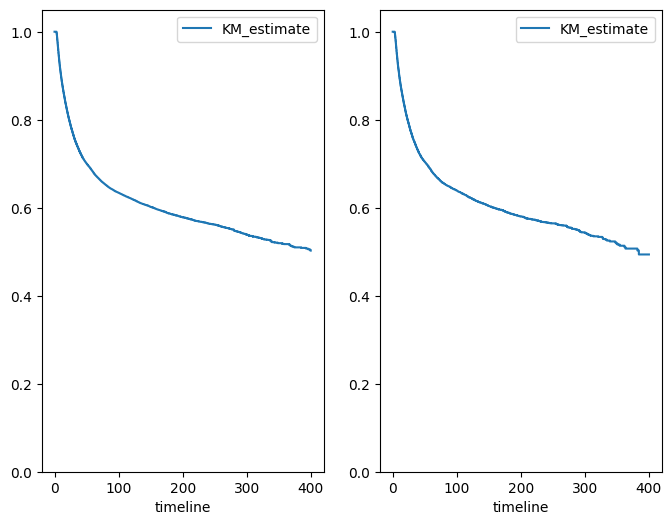

In [4]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (8,6))

km = lifelines.KaplanMeierFitter()
km.fit(df_train["tempo"], df_train["delta"])
km.plot(ax = ax[0], ci_show = False, show_censors = False)
ax[0].set_ylim(0,1.05)

km = lifelines.KaplanMeierFitter()
km.fit(df_test["tempo"], df_test["delta"])
km.plot(ax = ax[1], ci_show = False, show_censors = False)
ax[1].set_ylim(0,1.05)

plt.show()

### Splitting data into linear components and neural network inputs

In [5]:
y_train = df_train["tempo"].to_numpy() / 12
delta_train = df_train["delta"].to_numpy()
data_train = [y_train, delta_train]
X_train = df_train.iloc[:, 2:]

y_test = df_test["tempo"].to_numpy() / 12
delta_test = df_test["delta"].to_numpy()
data_test = [y_test, delta_test]
X_test = df_test.iloc[:, 2:]

In [6]:
linear_columns = [0, 3, 4, 5, 6, 7, 8, 9, 10, 11]
neuralnet_columns = [i for i in np.arange(X_train.shape[1]) if i not in linear_columns]

z_train = X_train.iloc[:, linear_columns]
# z_train.insert(0, "intercept", 1.0)
X_train_nn = X_train.iloc[:, neuralnet_columns]
# Projection weights matrix from z to X
# W_train_nn = np.linalg.inv( z_train.T @ z_train ) @ z_train.T @ X_train_nn

# By using @, the pandas environment breaks, since z_train and W_train_nn do not share colum names
# z_proj_X_train = np.dot(z_train, W_train_nn)

# Remove the projection of z_train from the matrix to be fed to the neural network
# X_train_nn = X_train_nn - z_proj_X_train

z_test = X_test.iloc[:, linear_columns]
# z_test.insert(0, "intercept", 1.0)
X_test_nn = X_test.iloc[:, neuralnet_columns]
# Projection weights matrix from z to X
# W_test_nn = np.linalg.inv( z_test.T @ z_test ) @ z_test.T @ X_test_nn
# z_proj_X_test = np.dot(z_test, W_test_nn)
# X_test_nn = X_test_nn - z_proj_X_test

data_train = [z_train, y_train, delta_train]
data_test = [z_test, y_test, delta_test]

display( z_train.head(3) )
display( X_train_nn.head(3) )

,idade,sexo_feminino,raca_amarela,raca_indigena,raca_parda,raca_preta,faixa_remuneracao_media_2 a 4 SM,faixa_remuneracao_media_4 a 7 SM,faixa_remuneracao_media_até 1 SM,faixa_remuneracao_media_mais de 7 SM
0,-1.283593,0,0,0,1,0,0,0,0,0
1,-0.582427,0,0,0,0,0,0,0,0,0
2,-0.757718,0,0,0,0,0,1,0,0,0


,horas_semanais,qtd_dias_afastamento,escolaridade_5 ano completo,escolaridade_6 a 9 ano incompleto,escolaridade_analfabeto,escolaridade_ate 5 ano incompleto,escolaridade_doutorado,escolaridade_fundamental completo,escolaridade_medio incompleto,escolaridade_mestrado,...,tamanho_estabelecimento_de 500 a 999 funcionarios,grupo_ocupacao_cbo_agropecuaria,grupo_ocupacao_cbo_diretores gerentes,grupo_ocupacao_cbo_industria producao,grupo_ocupacao_cbo_manutencao reparacao,grupo_ocupacao_cbo_profissionais nivel superior,grupo_ocupacao_cbo_servicos administrativos,grupo_ocupacao_cbo_tecnicos nivel medio,regime_jornada_jornada intermitente,regime_jornada_jornada parcial
0,0.39963,-0.15985,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0.39963,-0.15985,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0.39963,-0.15985,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


### Defining Proportional Hazard model structures

Below, we define proportional hazard models considering five different distributions: Exponential, Weibull, Log-normal, Log-logistic and Birnbaun-Saunders.

In [7]:
import utils_ph as ph

I0000 00:00:1781090030.382704   13572 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 17768 MB memory:  -> device: 0, name: NVIDIA RTX A4500, pci bus id: 0000:01:00.0, compute capability: 8.6


### Exponential model

In [8]:
# Quickly fit a no-covariates model to obtain satisfactory initial points
no_covariates_data_train = [data_train[1], data_train[2]]
seed = 10
exp_parameters, exp_loss = ph.get_simple_model( dist  = "exponential", theta_init = None )
simple_exp_model = thf.ModelNN(exp_parameters, exp_loss, None, None, None, input_dim = (1,), seed = seed)
simple_exp_model.train_model(epochs = 5000, x = None, data = no_covariates_data_train,
                             shuffle = True,
                             get_covariances = True,
                             validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                             force_training_validation = False,
                             optimizer_independent = optimizers.Adam(learning_rate = 0.1),
                             optimizer_nn = optimizers.Adam(learning_rate = 0.1),
                             early_stopping = True, early_stopping_patience = 10, 
                             early_stopping_warmup = 10,
                             reduce_lr = True, reduce_lr_warmup = 0,
                             reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-8, reduce_lr_patience = 5,
                             reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                             deterministic = True,
                             verbose = True, print_freq = 1,
                             train_batch_size = None, val_batch_size = None,
                             buffer_size = None, gradient_accumulation_steps = None)

init_scale = simple_exp_model.predict("scale")

print("\n-------------------- Optimal parameters ----------")
print("scale: {}".format(init_scale))

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 89 / 5000 ]  | Loss:  0.877103806 | Best Loss:  0.877097845 | Speed:  51  epoch/s    | Elapsed Time:  1.74436021  s    
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 5.262 seconds.

-------------------- Optimal parameters ----------
scale: [15.479222]


I0000 00:00:1781090036.725330   13572 cuda_solvers.cc:175] Creating GpuSolver handles for stream 0x57e8f4a74920


In [9]:
# Exponential
exp_parameters, exp_loss, exp_neural_network, exp_call, exp_call_nolast = \
ph.build_PH_model( z_train, dist = "exponential", theta_init = {"scale": init_scale}, beta_init = None )

In [10]:
with tf.device("/GPU:0"):
    seed = 10
    exp_model = thf.ModelNN(exp_parameters, exp_loss, exp_neural_network, exp_call, exp_call_nolast,
                            input_dim = (X_train_nn.shape[1],), seed = seed)
    exp_model.pre_train_model(epochs = None, x = X_train_nn, data = data_train, shuffle = True)
    exp_model.train_model(epochs = 5000, x = X_train_nn, data = data_train,
                          shuffle = True,
                          get_covariances = True,
                          validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                          force_training_validation = False,
                          optimizer_independent = optimizers.Adam(learning_rate = 0.001),
                          optimizer_nn = optimizers.Adam(learning_rate = 0.001),
                          fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                          early_stopping = True, early_stopping_patience = 10, 
                          early_stopping_warmup = 10,
                          reduce_lr = True, reduce_lr_warmup = 0,
                          reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 5,
                          reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                          fine_tune = True,
                          finetune_early_stopping = True, finetune_early_stopping_patience = 10,
                          finetune_early_stopping_warmup = 10,
                          finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                          finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-4, finetune_reduce_lr_patience = 5,
                          finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                          deterministic = True,
                          verbose = True, print_freq = 1,
                          train_batch_size = None, val_batch_size = None,
                          buffer_size = None, gradient_accumulation_steps = None)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 192 / 5000 ]  | Loss:  0.786127806 | Best Loss:  0.787114918 | Speed:  28  epoch/s    | Elapsed Time:  6.82996178  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 149 / 5000 ]  | Loss:  0.750705183 | Best Loss:  0.750783324 | Speed:  46  epoch/s    | Elapsed Time:  3.23564  s      
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 14.411 seconds.


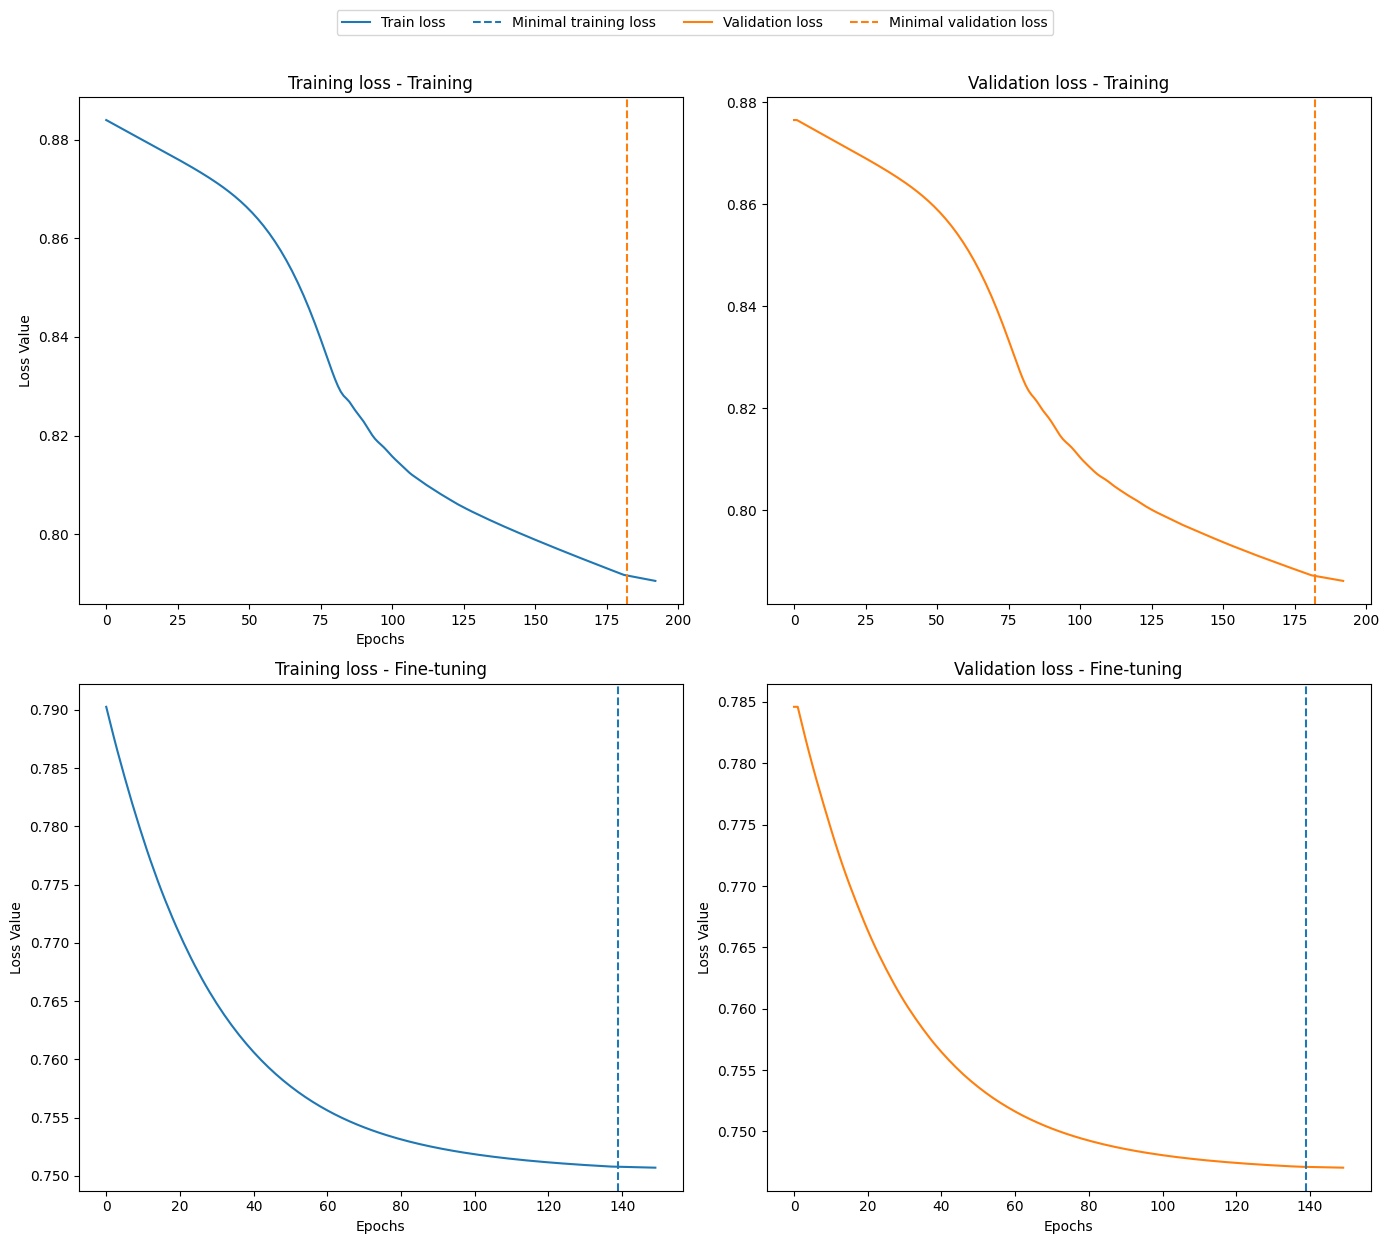

In [11]:
utils.plot_model_convergence( exp_model )

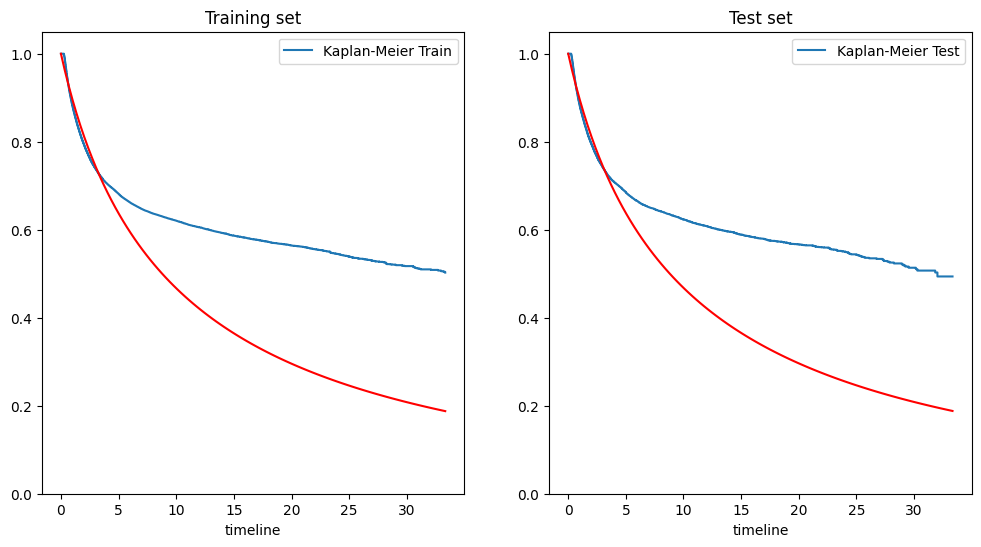

In [12]:
results_exp = ph.get_survival_exp(exp_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

# n_max = 2000
n_max = results_exp["S_ts_train"].shape[1]
train_idx = np.random.choice( np.arange(results_exp["S_ts_train"].shape[1]), size = np.min([n_max, results_exp["S_ts_train"].shape[1]]), replace = False )
test_idx = np.random.choice( np.arange(results_exp["S_ts_test"].shape[1]), size = np.min([n_max, results_exp["S_ts_test"].shape[1]]), replace = False )

utils.average_kaplan_meier(results_exp["ts_grid"].flatten(),
                           results_exp["S_ts_train"][:, train_idx], results_exp["S_ts_test"][:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [13]:
ph.summary_betas( exp_model, z_train.columns )

/home/garibay/codes/rais_analysis/Linear Final Models/modelnn2.py:2716: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta'].
  warnings.warn(


,Coef,Se,Z,pvalue,CI(95%)
idade,-0.555532,0.005412,-102.638650,0.000000,(-0.5661 ; -0.5449)
sexo_feminino,0.005336,0.010044,0.531307,0.595206,(-0.0143 ; 0.025)
raca_amarela,0.108296,0.045496,2.380323,0.017297,(0.0191 ; 0.1975)
raca_indigena,0.075438,0.091158,0.827552,0.407924,(-0.1032 ; 0.2541)
raca_parda,0.014067,0.010733,1.310621,0.189986,(-0.007 ; 0.0351)
raca_preta,0.075779,0.018310,4.138595,0.000035,(0.0399 ; 0.1117)
faixa_remuneracao_media_2 a 4 SM,-0.523252,0.015502,-33.754061,0.000000,(-0.5536 ; -0.4929)
faixa_remuneracao_media_4 a 7 SM,-0.611446,0.026393,-23.166667,0.000000,(-0.6632 ; -0.5597)
faixa_remuneracao_media_até 1 SM,0.781389,0.011395,68.574908,0.000000,(0.7591 ; 0.8037)
faixa_remuneracao_media_mais de 7 SM,-0.661665,0.030588,-21.631642,0.000000,(-0.7216 ; -0.6017)


### Weibull model

In [14]:
# Quickly fit a no-covariates model to obtain satisfactory initial points
no_covariates_data_train = [data_train[1], data_train[2]]

with tf.device("/GPU:0"):
    seed = 10
    weibull_parameters, weibull_loss = ph.get_simple_model( dist  = "weibull", theta_init = None )
    simple_weibull_model = thf.ModelNN(weibull_parameters, weibull_loss, None, None, None, input_dim = (1,), seed = seed)
    simple_weibull_model.train_model(epochs = 5000, x = None, data = no_covariates_data_train,
                                     shuffle = True,
                                     get_covariances = True,
                                     validation = False, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                     force_training_validation = False,
                                     optimizer_independent = optimizers.Adam(learning_rate = 0.1),
                                     optimizer_nn = optimizers.Adam(learning_rate = 0.1),
                                     early_stopping = True, early_stopping_patience = 10,
                                     early_stopping_warmup = 10,
                                     reduce_lr = True, reduce_lr_warmup = 0,
                                     reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-8, reduce_lr_patience = 5,
                                     reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                     deterministic = True,
                                     verbose = True, print_freq = 1,
                                     train_batch_size = None, val_batch_size = None,
                                     buffer_size = None, gradient_accumulation_steps = None)

init_shape = simple_weibull_model.predict("shape")
init_scale = simple_weibull_model.predict("scale")

print("\n-------------------- Optimal parameters ----------")
print("shape: {}".format(init_shape))
print("scale: {}".format(init_scale))

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 441 / 5000 ]  | Loss:  0.859828115 | Best Loss:  0.859828055 | Speed:  87  epoch/s    | Elapsed Time:  5.03924799  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 6.564 seconds.

-------------------- Optimal parameters ----------
shape: [0.7307338]
scale: [22.284575]


In [15]:
# Weibull
weibull_parameters, weibull_loss, weibull_neural_network, weibull_call, weibull_call_nolast = \
ph.build_PH_model( z_train, dist  = "weibull", theta_init = {"shape": init_shape, "scale": init_scale}, beta_init = None )

In [16]:
with tf.device("/GPU:0"):
    seed = 10
    weibull_model = thf.ModelNN(weibull_parameters, weibull_loss, weibull_neural_network, weibull_call, weibull_call_nolast,
                                input_dim = (X_train_nn.shape[1],), seed = seed)
    weibull_model.pre_train_model(epochs = None, x = X_train_nn, data = data_train, shuffle = True)
    weibull_model.train_model(epochs = 5000, x = X_train_nn, data = data_train,
                              shuffle = True,
                              get_covariances = True,
                              validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                              force_training_validation = False,
                              optimizer_independent = optimizers.Adam(learning_rate = 0.001),
                              optimizer_nn = optimizers.Adam(learning_rate = 0.001),
                              fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                              early_stopping = True, early_stopping_patience = 10, 
                              early_stopping_warmup = 50,
                              reduce_lr = True, reduce_lr_warmup = 0,
                              reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 5,
                              reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                              fine_tune = True,
                              finetune_early_stopping = True, finetune_early_stopping_patience = 10,
                              finetune_early_stopping_warmup = 50,
                              finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                              finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-4, finetune_reduce_lr_patience = 5,
                              # finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0, finetune_reduce_lr_patience = 5,
                              finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                              deterministic = True,
                              verbose = True, print_freq = 1,
                              train_batch_size = None, val_batch_size = None,
                              buffer_size = None, gradient_accumulation_steps = None)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 201 / 5000 ]  | Loss:  0.777054191 | Best Loss:  0.777919173 | Speed:  28  epoch/s    | Elapsed Time:  7.13580799  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 139 / 5000 ]  | Loss:  0.746293664 | Best Loss:  0.746372581 | Speed:  42  epoch/s    | Elapsed Time:  3.25172067  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 14.895 seconds.


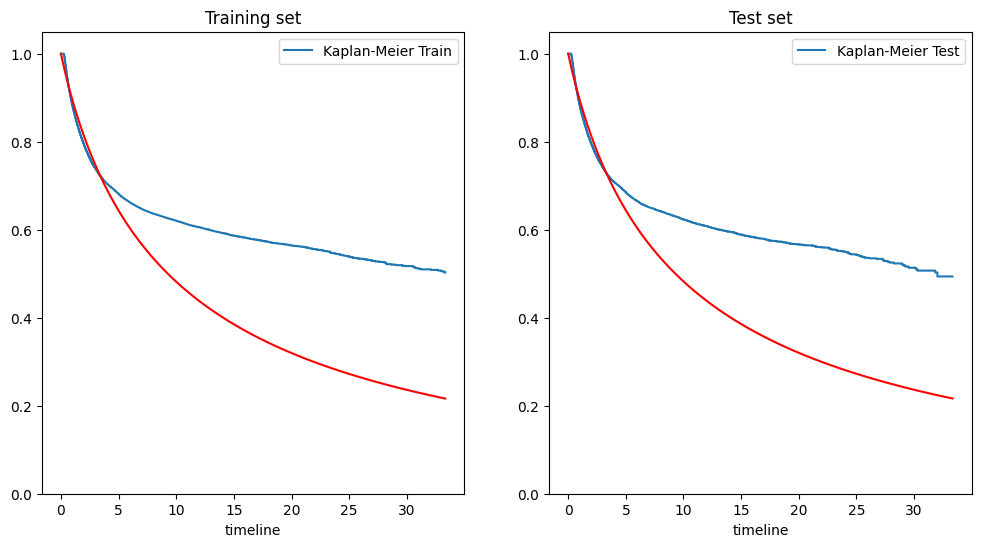

In [17]:
results_weibull = ph.get_survival_weibull(weibull_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

# n_max = 2000
n_max = results_weibull["S_ts_train"].shape[1]
train_idx = np.random.choice( np.arange(results_weibull["S_ts_train"].shape[1]), size = np.min([n_max, results_weibull["S_ts_train"].shape[1]]), replace = False )
test_idx = np.random.choice( np.arange(results_weibull["S_ts_test"].shape[1]), size = np.min([n_max, results_weibull["S_ts_test"].shape[1]]), replace = False )

utils.average_kaplan_meier(results_weibull["ts_grid"].flatten(),
                           results_weibull["S_ts_train"][:, train_idx], results_weibull["S_ts_test"][:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [18]:
ph.summary_betas( weibull_model, z_train.columns )

/home/garibay/codes/rais_analysis/Linear Final Models/modelnn2.py:2716: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta'].
  warnings.warn(


,Coef,Se,Z,pvalue,CI(95%)
idade,-0.540148,0.005802,-93.100762,0.000000e+00,(-0.5515 ; -0.5288)
sexo_feminino,0.076090,0.010507,7.241531,4.436451e-13,(0.0555 ; 0.0967)
raca_amarela,0.211481,0.045612,4.636518,3.543272e-06,(0.1221 ; 0.3009)
raca_indigena,0.197115,0.091088,2.164013,3.046336e-02,(0.0186 ; 0.3756)
raca_parda,0.130225,0.011474,11.349555,0.000000e+00,(0.1077 ; 0.1527)
raca_preta,0.182238,0.018702,9.744028,0.000000e+00,(0.1456 ; 0.2189)
faixa_remuneracao_media_2 a 4 SM,-0.478253,0.015824,-30.223793,0.000000e+00,(-0.5093 ; -0.4472)
faixa_remuneracao_media_4 a 7 SM,-0.567527,0.027176,-20.883751,0.000000e+00,(-0.6208 ; -0.5143)
faixa_remuneracao_media_até 1 SM,0.785988,0.011605,67.730959,0.000000e+00,(0.7632 ; 0.8087)
faixa_remuneracao_media_mais de 7 SM,-0.611900,0.032111,-19.055799,0.000000e+00,(-0.6748 ; -0.549)


### Log-normal model

In [19]:
# Quickly fit a no-covariates model to obtain satisfactory initial points
no_covariates_data_train = [data_train[1], data_train[2]]

with tf.device("/GPU:0"):
    seed = 10
    lognormal_parameters, lognormal_loss = ph.get_simple_model( dist  = "lognormal", theta_init = None )
    simple_lognormal_model = thf.ModelNN(lognormal_parameters, lognormal_loss, None, None, None, input_dim = (1,), seed = seed)
    simple_lognormal_model.train_model(epochs = 5000, x = None, data = no_covariates_data_train,
                                       shuffle = True,
                                       get_covariances = True,
                                       validation = False, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                       force_training_validation = False,
                                       optimizer_independent = optimizers.Adam(learning_rate = 0.1),
                                       optimizer_nn = optimizers.Adam(learning_rate = 0.1),
                                       early_stopping = True, early_stopping_patience = 10,
                                       early_stopping_warmup = 10,
                                       reduce_lr = True, reduce_lr_warmup = 0,
                                       reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-8, reduce_lr_patience = 5,
                                       reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                       deterministic = True,
                                       verbose = True, print_freq = 1,
                                       train_batch_size = None, val_batch_size = None,
                                       buffer_size = None, gradient_accumulation_steps = None)

init_mu = simple_lognormal_model.predict("mu")
init_scale = simple_lognormal_model.predict("scale")

print("\n-------------------- Optimal parameters ----------")
print("mu: {}".format(init_mu))
print("scale: {}".format(init_scale))

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 45 / 5000 ]  | Loss:  0.839108884 | Best Loss:  0.834803402 | Speed:  35  epoch/s    | Elapsed Time:  1.26387501  s    
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 3.313 seconds.

-------------------- Optimal parameters ----------
mu: [2.2411416]
scale: [1.7432594]


In [20]:
# Log-normal
lognormal_parameters, lognormal_loss, lognormal_neural_network, lognormal_call, lognormal_call_nolast = \
ph.build_PH_model( z_train, dist  = "lognormal", theta_init = {"mu": init_mu, "scale": init_scale}, beta_init = None )

In [21]:
with tf.device("/GPU:0"):
    seed = 10
    lognormal_model = thf.ModelNN(lognormal_parameters, lognormal_loss, lognormal_neural_network, lognormal_call, lognormal_call_nolast,
                                input_dim = (X_train_nn.shape[1],), seed = seed)
    lognormal_model.pre_train_model(epochs = None, x = X_train_nn, data = data_train, shuffle = True)
    lognormal_model.train_model(epochs = 5000, x = X_train_nn, data = data_train,
                                shuffle = True,
                                get_covariances = True,
                                validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                force_training_validation = False,
                                optimizer_independent = optimizers.Adam(learning_rate = 0.001),
                                optimizer_nn = optimizers.Adam(learning_rate = 0.001),
                                fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                                early_stopping = True, early_stopping_patience = 10, 
                                early_stopping_warmup = 50,
                                reduce_lr = True, reduce_lr_warmup = 0,
                                reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 5,
                                reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                fine_tune = True,
                                finetune_early_stopping = True, finetune_early_stopping_patience = 10,
                                finetune_early_stopping_warmup = 50,
                                finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                                finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-4, finetune_reduce_lr_patience = 5,
                                # finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0, finetune_reduce_lr_patience = 5,
                                finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                                deterministic = True,
                                verbose = True, print_freq = 1,
                                train_batch_size = None, val_batch_size = None,
                                buffer_size = None, gradient_accumulation_steps = None)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 163 / 5000 ]  | Loss:  0.750715613 | Best Loss:  0.751620471 | Speed:  32  epoch/s    | Elapsed Time:  5.02957058  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 144 / 5000 ]  | Loss:  0.716224611 | Best Loss:  0.716298938 | Speed:  38  epoch/s    | Elapsed Time:  3.73753142  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 14.078 seconds.


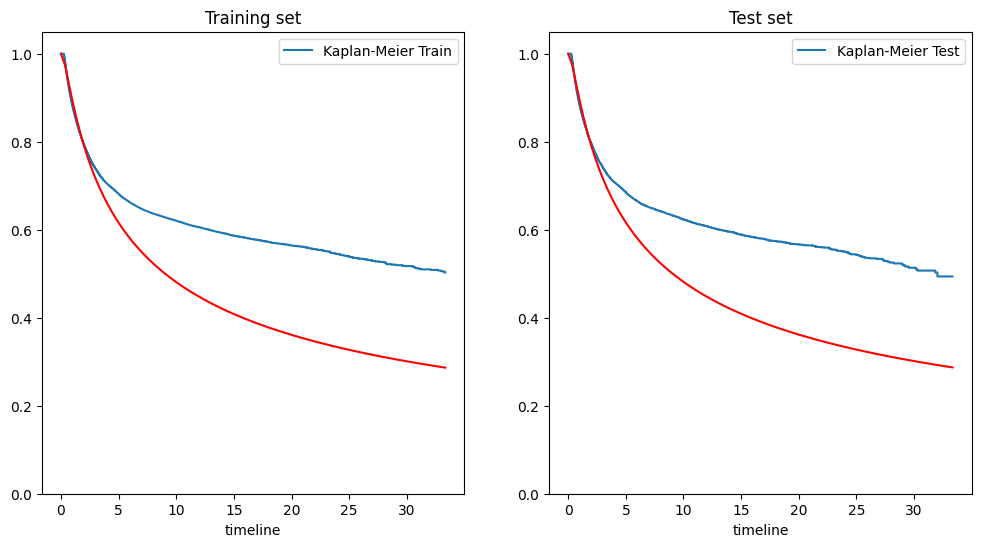

In [22]:
results_lognormal = ph.get_survival_lognormal(lognormal_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

# n_max = 2000
n_max = results_lognormal["S_ts_train"].shape[1]
train_idx = np.random.choice( np.arange(results_lognormal["S_ts_train"].shape[1]), size = np.min([n_max, results_lognormal["S_ts_train"].shape[1]]), replace = False )
test_idx = np.random.choice( np.arange(results_lognormal["S_ts_test"].shape[1]), size = np.min([n_max, results_lognormal["S_ts_test"].shape[1]]), replace = False )

utils.average_kaplan_meier(results_lognormal["ts_grid"].flatten(),
                           results_lognormal["S_ts_train"][:, train_idx], results_lognormal["S_ts_test"][:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [23]:
ph.summary_betas( lognormal_model, z_train.columns )

/home/garibay/codes/rais_analysis/Linear Final Models/modelnn2.py:2716: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta'].
  warnings.warn(


,Coef,Se,Z,pvalue,CI(95%)
idade,-0.500971,0.005527,-90.647757,0.000000e+00,(-0.5118 ; -0.4901)
sexo_feminino,-0.050310,0.010102,-4.980319,6.347953e-07,(-0.0701 ; -0.0305)
raca_amarela,0.067830,0.045454,1.492296,1.356215e-01,(-0.0213 ; 0.1569)
raca_indigena,0.037498,0.091196,0.411179,6.809412e-01,(-0.1412 ; 0.2162)
raca_parda,-0.039386,0.010668,-3.692012,2.224872e-04,(-0.0603 ; -0.0185)
raca_preta,0.033413,0.018256,1.830292,6.720634e-02,(-0.0024 ; 0.0692)
faixa_remuneracao_media_2 a 4 SM,-0.507894,0.015469,-32.832397,0.000000e+00,(-0.5382 ; -0.4776)
faixa_remuneracao_media_4 a 7 SM,-0.582133,0.026678,-21.820849,0.000000e+00,(-0.6344 ; -0.5298)
faixa_remuneracao_media_até 1 SM,0.782432,0.011439,68.400839,0.000000e+00,(0.76 ; 0.8049)
faixa_remuneracao_media_mais de 7 SM,-0.636768,0.031472,-20.232590,0.000000e+00,(-0.6985 ; -0.5751)


### Log-logistic model

In [24]:
# Quickly fit a no-covariates model to obtain satisfactory initial points
no_covariates_data_train = [data_train[1], data_train[2]]

with tf.device("/GPU:0"):
    seed = 10
    loglogistic_parameters, loglogistic_loss = ph.get_simple_model( dist  = "loglogistic", theta_init = None )
    simple_loglogistic_model = thf.ModelNN(loglogistic_parameters, loglogistic_loss, None, None, None, input_dim = (1,), seed = seed)
    simple_loglogistic_model.train_model(epochs = 5000, x = None, data = no_covariates_data_train,
                                         shuffle = True,
                                         get_covariances = True,
                                         validation = False, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                         force_training_validation = False,
                                         optimizer_independent = optimizers.Adam(learning_rate = 0.1),
                                         optimizer_nn = optimizers.Adam(learning_rate = 0.1),
                                         early_stopping = True, early_stopping_patience = 10,
                                         early_stopping_warmup = 10,
                                         reduce_lr = True, reduce_lr_warmup = 0,
                                         reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-8, reduce_lr_patience = 5,
                                         reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                         deterministic = True,
                                         verbose = True, print_freq = 1,
                                         train_batch_size = None, val_batch_size = None,
                                         buffer_size = None, gradient_accumulation_steps = None)

init_shape = simple_loglogistic_model.predict("shape")
init_scale = simple_loglogistic_model.predict("scale")

print("\n-------------------- Optimal parameters ----------")
print("shape: {}".format(init_shape))
print("scale: {}".format(init_scale))

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 52 / 5000 ]  | Loss:  0.848789871 | Best Loss:  0.847458065 | Speed:  90  epoch/s    | Elapsed Time:  0.576340675  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 2.087 seconds.

-------------------- Optimal parameters ----------
shape: [0.8928011]
scale: [10.875302]


In [25]:
# Log-logistic
loglogistic_parameters, loglogistic_loss, loglogistic_neural_network, loglogistic_call, loglogistic_call_nolast = \
ph.build_PH_model( z_train, dist  = "loglogistic", theta_init = {"shape": init_shape, "scale": init_scale}, beta_init = None )

In [26]:
with tf.device("/GPU:0"):
    seed = 10
    loglogistic_model = thf.ModelNN(loglogistic_parameters, loglogistic_loss, loglogistic_neural_network, loglogistic_call, loglogistic_call_nolast,
                                    input_dim = (X_train_nn.shape[1],), seed = seed)
    loglogistic_model.pre_train_model(epochs = None, x = X_train_nn, data = data_train, shuffle = True)
    loglogistic_model.train_model(epochs = 5000, x = X_train_nn, data = data_train,
                                  shuffle = True,
                                  get_covariances = True,
                                  validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                  force_training_validation = False,
                                  optimizer_independent = optimizers.Adam(learning_rate = 0.001),
                                  optimizer_nn = optimizers.Adam(learning_rate = 0.001),
                                  fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                                  early_stopping = True, early_stopping_patience = 10, 
                                  early_stopping_warmup = 50,
                                  reduce_lr = True, reduce_lr_warmup = 0,
                                  reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 5,
                                  reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                  fine_tune = True,
                                  finetune_early_stopping = True, finetune_early_stopping_patience = 10,
                                  finetune_early_stopping_warmup = 50,
                                  finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                                  finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-4, finetune_reduce_lr_patience = 5,
                                  # finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0, finetune_reduce_lr_patience = 5,
                                  finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                                  deterministic = True,
                                  verbose = True, print_freq = 1,
                                  train_batch_size = None, val_batch_size = None,
                                  buffer_size = None, gradient_accumulation_steps = None)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 184 / 5000 ]  | Loss:  0.766109109 | Best Loss:  0.767028451 | Speed:  27  epoch/s    | Elapsed Time:  6.60323858  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 142 / 5000 ]  | Loss:  0.734434485 | Best Loss:  0.734513879 | Speed:  44  epoch/s    | Elapsed Time:  3.19740987  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 14.025 seconds.


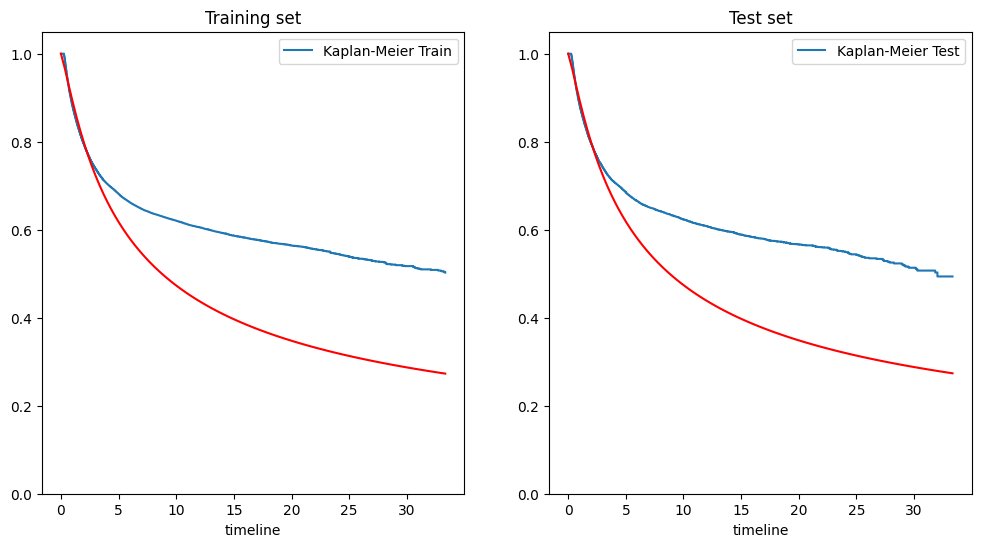

In [27]:
results_loglogistic = ph.get_survival_loglogistic(loglogistic_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

# n_max = 2000
n_max = results_loglogistic["S_ts_train"].shape[1]
train_idx = np.random.choice( np.arange(results_loglogistic["S_ts_train"].shape[1]), size = np.min([n_max, results_loglogistic["S_ts_train"].shape[1]]), replace = False )
test_idx = np.random.choice( np.arange(results_loglogistic["S_ts_test"].shape[1]), size = np.min([n_max, results_loglogistic["S_ts_test"].shape[1]]), replace = False )

utils.average_kaplan_meier(results_loglogistic["ts_grid"].flatten(),
                           results_loglogistic["S_ts_train"][:, train_idx], results_loglogistic["S_ts_test"][:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [28]:
ph.summary_betas( loglogistic_model, z_train.columns )

/home/garibay/codes/rais_analysis/Linear Final Models/modelnn2.py:2716: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta'].
  warnings.warn(


,Coef,Se,Z,pvalue,CI(95%)
idade,-0.519856,0.005576,-93.233260,0.000000e+00,(-0.5308 ; -0.5089)
sexo_feminino,-0.047502,0.010207,-4.654059,3.254639e-06,(-0.0675 ; -0.0275)
raca_amarela,0.042671,0.045562,0.936559,3.489853e-01,(-0.0466 ; 0.132)
raca_indigena,0.013637,0.091285,0.149394,8.812429e-01,(-0.1653 ; 0.1926)
raca_parda,-0.061440,0.011158,-5.506303,3.664472e-08,(-0.0833 ; -0.0396)
raca_preta,-0.002335,0.018520,-0.126096,8.996561e-01,(-0.0386 ; 0.034)
faixa_remuneracao_media_2 a 4 SM,-0.535098,0.015570,-34.368184,0.000000e+00,(-0.5656 ; -0.5046)
faixa_remuneracao_media_4 a 7 SM,-0.601484,0.026410,-22.775163,0.000000e+00,(-0.6532 ; -0.5497)
faixa_remuneracao_media_até 1 SM,0.769198,0.011407,67.432173,0.000000e+00,(0.7468 ; 0.7916)
faixa_remuneracao_media_mais de 7 SM,-0.643111,0.030798,-20.881496,0.000000e+00,(-0.7035 ; -0.5827)


### BS model

In [29]:
# Quickly fit a no-covariates model to obtain satisfactory initial points
no_covariates_data_train = [data_train[1], data_train[2]]

with tf.device("/GPU:0"):
    seed = 10
    bs_parameters, bs_loss = ph.get_simple_model( dist  = "bs", theta_init = None )
    simple_bs_model = thf.ModelNN(bs_parameters, bs_loss, None, None, None, input_dim = (1,), seed = seed)
    simple_bs_model.train_model(epochs = 5000, x = None, data = no_covariates_data_train,
                                shuffle = True,
                                get_covariances = True,
                                validation = False, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                force_training_validation = False,
                                optimizer_independent = optimizers.Adam(learning_rate = 0.05),
                                optimizer_nn = optimizers.Adam(learning_rate = 0.05),
                                early_stopping = True, early_stopping_patience = 10,
                                early_stopping_warmup = 10,
                                reduce_lr = True, reduce_lr_warmup = 0,
                                reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-8, reduce_lr_patience = 5,
                                reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                deterministic = True,
                                verbose = True, print_freq = 1,
                                train_batch_size = None, val_batch_size = None,
                                buffer_size = None, gradient_accumulation_steps = None)

init_shape = simple_bs_model.predict("shape")
init_scale = simple_bs_model.predict("scale")

print("\n-------------------- Optimal parameters ----------")
print("shape: {}".format(init_shape))
print("scale: {}".format(init_scale))

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 1780 / 5000 ]  | Loss:  0.790102422 | Best Loss:  0.790102422 | Speed:  75  epoch/s    | Elapsed Time:  23.5317974  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 25.805 seconds.

-------------------- Optimal parameters ----------
shape: [4.8789134]
scale: [37.68612]


In [30]:
# Birnbaun-Saunders (BS)
bs_parameters, bs_loss, bs_neural_network, bs_call, bs_call_nolast = \
ph.build_PH_model( z_train, dist  = "bs", theta_init = {"shape": init_shape, "scale": init_scale}, beta_init = None )

In [31]:
with tf.device("/GPU:0"):
    seed = 10
    bs_model = thf.ModelNN(bs_parameters, bs_loss, bs_neural_network, bs_call, bs_call_nolast,
                           input_dim = (X_train_nn.shape[1],), seed = seed)
    bs_model.pre_train_model(epochs = None, x = X_train_nn, data = data_train, shuffle = True)
    bs_model.train_model(epochs = 5000, x = X_train_nn, data = data_train,
                         shuffle = True,
                         get_covariances = True,
                         validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                         force_training_validation = False,
                         optimizer_independent = optimizers.Adam(learning_rate = 0.001),
                         optimizer_nn = optimizers.Adam(learning_rate = 0.001),
                         fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                         early_stopping = True, early_stopping_patience = 10, 
                         early_stopping_warmup = 50,
                         reduce_lr = True, reduce_lr_warmup = 0,
                         reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 5,
                         reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                         fine_tune = True,
                         finetune_early_stopping = True, finetune_early_stopping_patience = 10,
                         finetune_early_stopping_warmup = 50,
                         finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                         finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-4, finetune_reduce_lr_patience = 5,
                         # finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0, finetune_reduce_lr_patience = 5,
                         finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                         deterministic = True,
                         verbose = True, print_freq = 1,
                         train_batch_size = None, val_batch_size = None,
                         buffer_size = None, gradient_accumulation_steps = None)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 137 / 5000 ]  | Loss:  0.744379699 | Best Loss:  0.745232046 | Speed:  25  epoch/s    | Elapsed Time:  5.41788769  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 169 / 5000 ]  | Loss:  0.708116353 | Best Loss:  0.708188534 | Speed:  39  epoch/s    | Elapsed Time:  4.31086445  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 13.874 seconds.


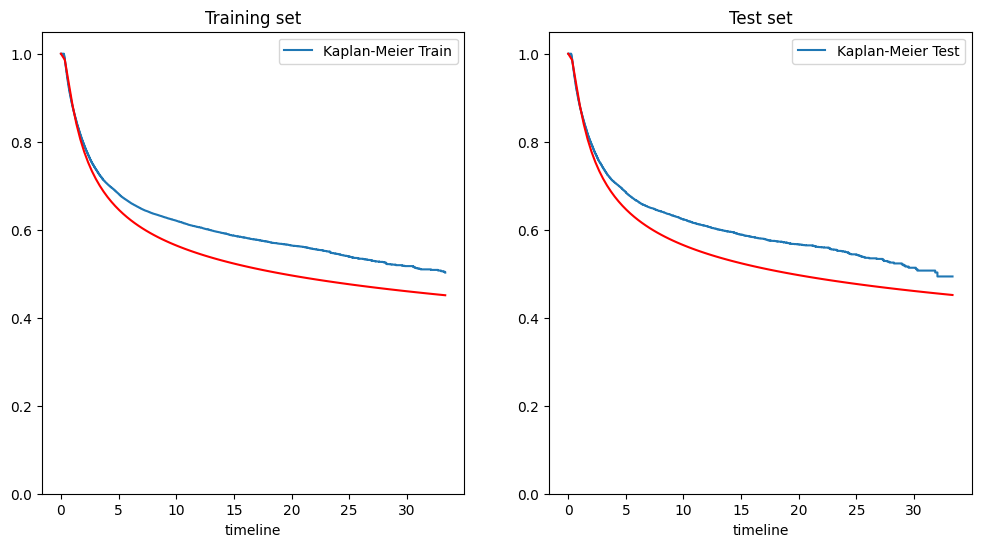

In [32]:
results_bs = ph.get_survival_bs(bs_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

# n_max = 2000
n_max = results_bs["S_ts_train"].shape[1]
train_idx = np.random.choice( np.arange(results_bs["S_ts_train"].shape[1]), size = np.min([n_max, results_bs["S_ts_train"].shape[1]]), replace = False )
test_idx = np.random.choice( np.arange(results_bs["S_ts_test"].shape[1]), size = np.min([n_max, results_bs["S_ts_test"].shape[1]]), replace = False )

utils.average_kaplan_meier(results_bs["ts_grid"].flatten(),
                           results_bs["S_ts_train"][:, train_idx], results_bs["S_ts_test"][:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [33]:
ph.summary_betas( bs_model, z_train.columns )

/home/garibay/codes/rais_analysis/Linear Final Models/modelnn2.py:2716: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta'].
  warnings.warn(


,Coef,Se,Z,pvalue,CI(95%)
idade,-0.472377,0.005436,-86.902611,0.000000e+00,(-0.483 ; -0.4617)
sexo_feminino,0.054686,0.008936,6.119422,9.391510e-10,(0.0372 ; 0.0722)
raca_amarela,0.246005,0.045004,5.466341,4.594211e-08,(0.1578 ; 0.3342)
raca_indigena,0.249004,0.090710,2.745071,6.049772e-03,(0.0712 ; 0.4268)
raca_parda,0.141491,0.007206,19.634523,0.000000e+00,(0.1274 ; 0.1556)
raca_preta,0.204719,0.016320,12.543976,0.000000e+00,(0.1727 ; 0.2367)
faixa_remuneracao_media_2 a 4 SM,-0.446120,0.013720,-32.515506,0.000000e+00,(-0.473 ; -0.4192)
faixa_remuneracao_media_4 a 7 SM,-0.599393,0.026213,-22.866207,0.000000e+00,(-0.6508 ; -0.548)
faixa_remuneracao_media_até 1 SM,0.857584,0.010812,79.316520,0.000000e+00,(0.8364 ; 0.8788)
faixa_remuneracao_media_mais de 7 SM,-0.717611,0.031424,-22.836612,0.000000e+00,(-0.7792 ; -0.656)


## Comparing all models

In [34]:
# Takes only employees whose sallary is the standard (between 1 and 2 minimal salaries)
baseline_idx = (X_train.iloc[:, [8,9,10,11]] == 0).all(axis = 1)
X_baseline = X_train.loc[ baseline_idx , : ]
y_baseline = y_train[ baseline_idx ]
delta_baseline = delta_train[ baseline_idx ]

z_baseline = X_baseline.iloc[:, linear_columns]
z_baseline_tf = tf.cast(z_baseline, tf.float32)
X_baseline_nn = X_baseline.iloc[:, neuralnet_columns]
# y_baseline = 

ate1sm_idx = X_train["faixa_remuneracao_media_até 1 SM"] == 1
X_ate1sm = X_train.loc[ ate1sm_idx , : ]
y_ate1sm = y_train[ ate1sm_idx ]
delta_ate1sm = delta_train[ ate1sm_idx ]

z_ate1sm = X_ate1sm.iloc[:, linear_columns]
z_ate1sm_tf = tf.cast(z_ate1sm, tf.float32)
X_ate1sm_nn = X_ate1sm.iloc[:, neuralnet_columns]

In [35]:
results_exp_baseline = ph.get_survival_exp(exp_model, y_baseline, z_baseline_tf, X_baseline_nn, y_baseline, z_baseline_tf, X_baseline_nn, ngrid = 100)
results_exp_ate1sm = ph.get_survival_exp(exp_model, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, ngrid = 100)

results_weibull_baseline = ph.get_survival_weibull(weibull_model, y_baseline, z_baseline_tf, X_baseline_nn, y_baseline, z_baseline_tf, X_baseline_nn, ngrid = 100)
results_weibull_ate1sm = ph.get_survival_weibull(weibull_model, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, ngrid = 100)

results_lognormal_baseline = ph.get_survival_lognormal(lognormal_model, y_baseline, z_baseline_tf, X_baseline_nn, y_baseline, z_baseline_tf, X_baseline_nn, ngrid = 100)
results_lognormal_ate1sm = ph.get_survival_lognormal(lognormal_model, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, ngrid = 100)

results_loglogistic_baseline = ph.get_survival_loglogistic(loglogistic_model, y_baseline, z_baseline_tf, X_baseline_nn, y_baseline, z_baseline_tf, X_baseline_nn, ngrid = 100)
results_loglogistic_ate1sm = ph.get_survival_loglogistic(loglogistic_model, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, ngrid = 100)

results_bs_baseline = ph.get_survival_bs(bs_model, y_baseline, z_baseline_tf, X_baseline_nn, y_baseline, z_baseline_tf, X_baseline_nn, ngrid = 100)
results_bs_ate1sm = ph.get_survival_bs(bs_model, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, ngrid = 100)

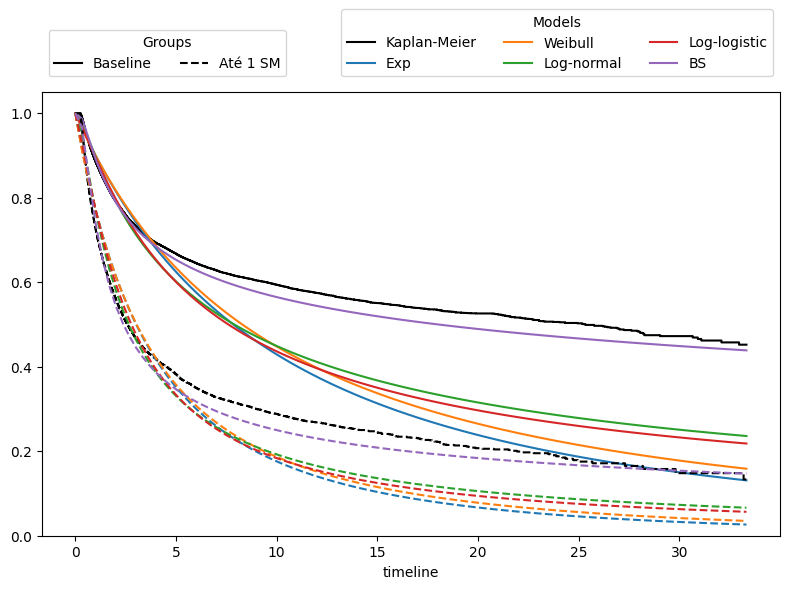

In [40]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

# ax.plot(ts_grid.numpy().flatten(), np.mean( S_ts_baseline, axis = 1 ), color = colors[0])

km_baseline = lifelines.KaplanMeierFitter()
km_baseline.fit(y_baseline, delta_baseline)
km_baseline.plot(ax = ax, ci_show = False, show_censors = False, label = "Baseline", color = "black", linestyle = "-")
ax.set_ylim(0,1.05)

ax.plot(results_exp_baseline["ts_grid"].flatten(), np.mean( results_exp_baseline["S_ts_train"], axis = 1 ), color = colors[0], label = "Exp")
ax.plot(results_weibull_baseline["ts_grid"].flatten(), np.mean( results_weibull_baseline["S_ts_train"], axis = 1 ), color = colors[1], label = "Weibull")
ax.plot(results_lognormal_baseline["ts_grid"].flatten(), np.mean( results_lognormal_baseline["S_ts_train"], axis = 1 ), color = colors[2], label = "Weibull")
ax.plot(results_loglogistic_baseline["ts_grid"].flatten(), np.mean( results_loglogistic_baseline["S_ts_train"], axis = 1 ), color = colors[3], label = "Weibull")
ax.plot(results_bs_baseline["ts_grid"].flatten(), np.mean( results_bs_baseline["S_ts_train"], axis = 1 ), color = colors[4], label = "Weibull")

km_ate1sm = lifelines.KaplanMeierFitter()
km_ate1sm.fit(y_ate1sm, delta_ate1sm)
km_ate1sm.plot(ax = ax, ci_show = False, show_censors = False, label = "Até 1 SM", color = "black", linestyle = "--")
ax.set_ylim(0,1.05)

ax.plot(results_exp_ate1sm["ts_grid"].flatten(), np.mean( results_exp_ate1sm["S_ts_train"], axis = 1 ), color = colors[0], linestyle = "--")
ax.plot(results_weibull_ate1sm["ts_grid"].flatten(), np.mean( results_weibull_ate1sm["S_ts_train"], axis = 1 ), color = colors[1], linestyle = "--")
ax.plot(results_lognormal_ate1sm["ts_grid"].flatten(), np.mean( results_lognormal_ate1sm["S_ts_train"], axis = 1 ), color = colors[2], linestyle = "--")
ax.plot(results_loglogistic_ate1sm["ts_grid"].flatten(), np.mean( results_loglogistic_ate1sm["S_ts_train"], axis = 1 ), color = colors[3], linestyle = "--")
ax.plot(results_bs_ate1sm["ts_grid"].flatten(), np.mean( results_bs_ate1sm["S_ts_train"], axis = 1 ), color = colors[4], linestyle = "--")

# Custom handles for Line Styles (The Groups)
group_handles = [
    Line2D([0], [0], color='black', linestyle='-', label='Baseline'),
    Line2D([0], [0], color='black', linestyle='--', label='Até 1 SM')
]

# Custom handles for Colors (The Models)
model_handles = [
    Line2D([0], [0], color='black', linestyle='-', label='Kaplan-Meier'),
    Line2D([0], [0], color=colors[0], linestyle='-', label='Exp'),
    Line2D([0], [0], color=colors[1], linestyle='-', label='Weibull'),
    Line2D([0], [0], color=colors[2], linestyle='-', label='Log-normal'),
    Line2D([0], [0], color=colors[3], linestyle='-', label='Log-logistic'),
    Line2D([0], [0], color=colors[4], linestyle='-', label='BS')
]

# Add the first legend (Groups) - Anchored to the top left
legend1 = ax.legend(
    handles = group_handles, 
    loc = 'lower left', 
    bbox_to_anchor = (0.0, 1.02), # Pushes it just above the top-left corner
    title = "Groups",
    ncol = 2                     # Lays items out horizontally
)

ax.add_artist(legend1) 

# Add the second legend (Models) - Anchored to the top right
ax.legend(
    handles = model_handles, 
    loc = 'lower right', 
    bbox_to_anchor = (1.0, 1.02), # Pushes it just above the top-right corner
    title = "Models",
    ncol = 3,                     # Lays items out horizontally
)

# Prevent the top legends from being clipped off the final image
plt.tight_layout() 
plt.show()